In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
#Load the datset

df = pd.read_csv(r'C:\Users\rsrmo\Documents\Data Analyst_ Portfolio\SalesDashboard\data\cosmetics_sales_data.csv')

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Sales Person   374 non-null    object        
 1   Country        374 non-null    object        
 2   Product        374 non-null    object        
 3   Date           374 non-null    datetime64[ns]
 4    Amount ($)    374 non-null    object        
 5   Boxes Shipped  374 non-null    int64         
 6   Sales per box  374 non-null    object        
 7   Month          374 non-null    period[M]     
dtypes: datetime64[ns](1), int64(1), object(5), period[M](1)
memory usage: 23.5+ KB


In [23]:
df.head()

,Sales Person,Country,Product,Date,Amount ($),Boxes Shipped,Sales per box,Month
0,Lucas Verma,Canada,Aloe Vera Gel,2022-04-30,"$7,897",358,$22,2022-04
1,Ethan Reddy,UK,Aloe Vera Gel,2022-01-25,"$16,377",449,$36,2022-01
2,Ananya Gupta,India,Body Butter Cream,2022-08-22,"$5,600",264,$21,2022-08
3,Ananya Gupta,New Zealand,Salicylic Acid Cleanser,2022-08-26,"$2,966",144,$21,2022-08
4,Sophia Nair,UK,Body Butter Cream,2022-05-19,"$6,829",484,$14,2022-05


In [25]:
#cleaning column names

df.columns = df.columns.str.strip().str.replace(" ", "_").str.replace("(", "").str.replace(")", "").str.replace("$", "")

In [34]:
# Convert 'Date' column to datetime
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y', errors='coerce')

# Now you can safely use .dt
df['Month'] = df['Date'].dt.to_period('M')

In [36]:
df.head()

,Sales_Person,Country,Product,Date,Amount_,Boxes_Shipped,Sales_per_box,Month
0,Lucas Verma,Canada,Aloe Vera Gel,2022-04-30,"$7,897",358,$22,2022-04
1,Ethan Reddy,UK,Aloe Vera Gel,2022-01-25,"$16,377",449,$36,2022-01
2,Ananya Gupta,India,Body Butter Cream,2022-08-22,"$5,600",264,$21,2022-08
3,Ananya Gupta,New Zealand,Salicylic Acid Cleanser,2022-08-26,"$2,966",144,$21,2022-08
4,Sophia Nair,UK,Body Butter Cream,2022-05-19,"$6,829",484,$14,2022-05


In [40]:
# Clean Amount_ column to make it numeric
df['Amount_'] = (
    df['Amount_']
    .astype(str)                 
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip()
)

# Handle cases where multiple numbers appear in one cell
# (like "$7,897  $442  $3,900") — take only the first numeric value
df['Amount_'] = df['Amount_'].str.extract(r'(\d+\.?\d*)')

# Convert to float
df['Amount_'] = pd.to_numeric(df['Amount_'], errors='coerce')

In [42]:
#EDA

# Total Sales by Country

sales_by_country = df.groupby('Country')['Amount_'].sum().sort_values(ascending=False)
print("\nTotal Sales by Country:\n", sales_by_country)



Total Sales by Country:
 Country
USA            628485
New Zealand    557061
Australia      505500
UK             497062
Canada         374563
India          346436
Name: Amount_, dtype: int64


In [44]:
# Total Sales by Product
sales_by_product = df.groupby('Product')['Amount_'].sum().sort_values(ascending=False)
print("\nTotal Sales by Product:\n", sales_by_product.head(10))


Total Sales by Product:
 Product
Tea Tree Moisturizer    260906
Hydrating Face Serum    250320
Hair Repair Oil         232867
Anti-Aging Serum        232247
Body Butter Cream       222924
SPF 50 Sunscreen        218577
Vitamin C Cream         218210
Aloe Vera Gel           202900
Face Sheet Masks        197882
Under Eye Cream         195939
Name: Amount_, dtype: int64


In [46]:
# Monthly trend
monthly_sales = df.groupby('Month')['Amount_'].sum()
print("\nMonthly Sales Trend:\n", monthly_sales)


Monthly Sales Trend:
 Month
2022-01    359764
2022-02    214024
2022-03    484104
2022-04    452650
2022-05    396611
2022-06    366999
2022-07    359655
2022-08    275300
Freq: M, Name: Amount_, dtype: int64


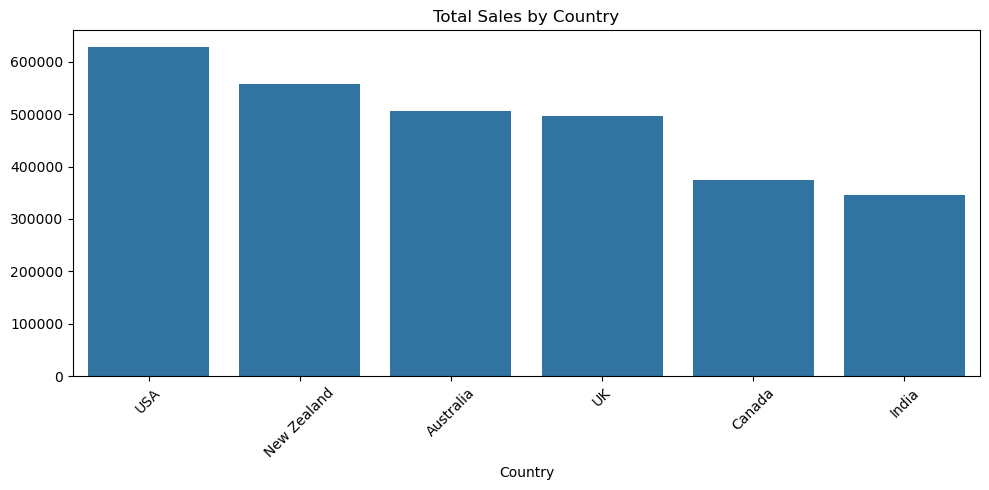

In [48]:
#Data Visualization

# Total Sales by Countr
plt.figure(figsize=(10,5))
sns.barplot(x=sales_by_country.index, y=sales_by_country.values)
plt.title("Total Sales by Country")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

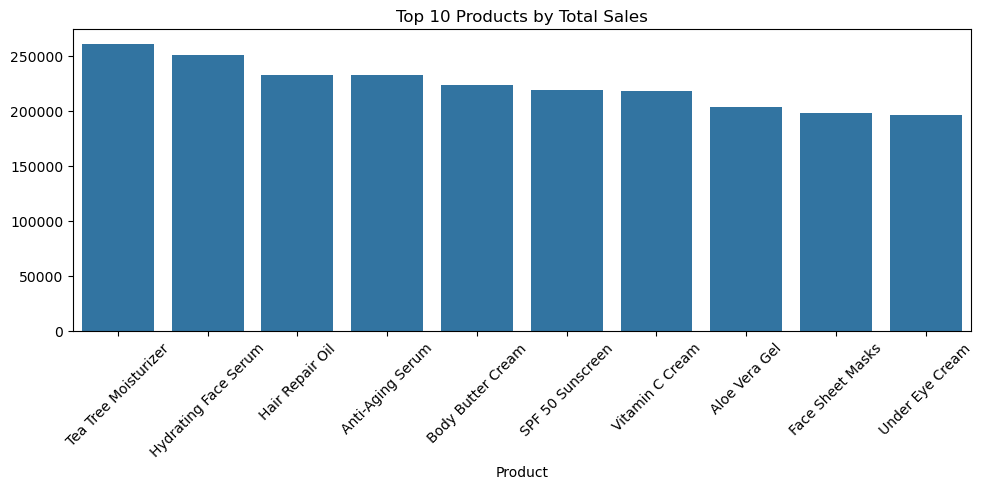

In [50]:
# Top 10 Products by Sales
plt.figure(figsize=(10,5))
sns.barplot(x=sales_by_product.head(10).index, y=sales_by_product.head(10).values)
plt.title("Top 10 Products by Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

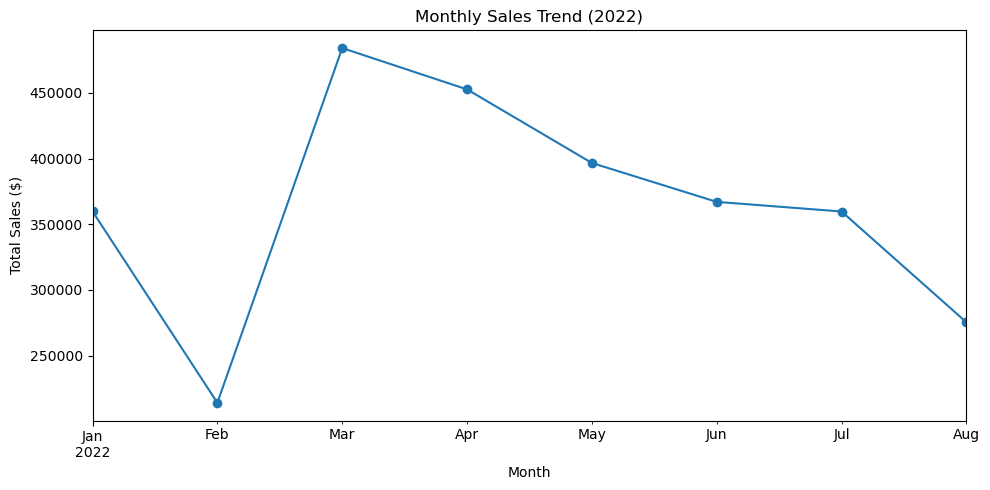

In [52]:
# Monthly Sales Trend
plt.figure(figsize=(10,5))
monthly_sales.plot(kind='line', marker='o')
plt.title("Monthly Sales Trend (2022)")
plt.ylabel("Total Sales ($)")
plt.xlabel("Month")
plt.tight_layout()
plt.show()

In [64]:
df.to_csv(r'C:\Users\rsrmo\Documents\Data Analyst_ Portfolio\SalesDashboard\notebooks\cosmetics_sales_data_cleaned.csv', index=False)
print("\n✅ Cleaned data saved")


✅ Cleaned data saved
